# 🧪 Taller - Ojos Digitales: Introducción a la Visión Artificial

## 🔍 Objetivo
Este taller introduce los fundamentos de la visión artificial mediante el procesamiento de imágenes en escala de grises, la aplicación de filtros convolucionales y la detección de bordes. Utilizaremos **OpenCV** y **NumPy** para explorar cómo los computadores interpretan imágenes, y **Matplotlib** para visualizar los resultados.

## 📋 Actividades
- Cargar una imagen a color y convertirla a escala de grises.
- Aplicar filtros convolucionales (blur y sharpening).
- Implementar detección de bordes con Sobel (X e Y) y Laplaciano.
- Comparar visualmente los resultados.
- Implementar sliders interactivos para ajustar parámetros (tamaño del kernel).

## 🛠️ Herramientas
- Python
- Librerías: `opencv-python`, `numpy`, `matplotlib`

⚠️ **Nota**: Asegúrate de tener una imagen de prueba (e.g., `image.jpg`) en el directorio de trabajo. Si usas Colab, sube la imagen manualmente.

## 1. Instalación e Importación de Librerías

Primero, instalamos las librerías necesarias (si no están ya instaladas) y las importamos. En Colab, `opencv-python` y `matplotlib` suelen estar preinstalados, pero verificamos para entornos locales.

In [1]:
# Instalación de librerías
!pip install opencv-python numpy matplotlib

# Importar librerías
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Configurar Matplotlib para mostrar imágenes en el notebook
%matplotlib inline

## 2. Cargar y Convertir Imagen a Escala de Grises

Cargamos una imagen a color utilizando `cv2.imread()` y la convertimos a escala de grises con `cv2.cvtColor()`. Mostramos ambas imágenes para verificar el proceso.

- **Entrada**: Imagen a color en formato BGR (formato por defecto de OpenCV).
- **Salida**: Imagen en escala de grises (un solo canal).

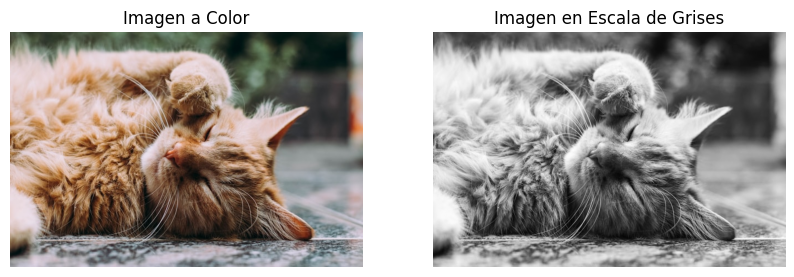

In [2]:
# Cargar imagen
image_path = 'sample_image.jpg'  # Reemplaza con el nombre de tu imagen
img_color = cv2.imread(image_path)

# Verificar si la imagen se cargó correctamente
if img_color is None:
    raise FileNotFoundError('No se pudo cargar la imagen. Verifica la ruta.')

# Convertir a escala de grises
img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

# Visualizar imágenes
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title('Imagen a Color')
plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))  # Convertir BGR a RGB para Matplotlib
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Imagen en Escala de Grises')
plt.imshow(img_gray, cmap='gray')
plt.axis('off')

plt.show()

## 3. Aplicar Filtros Convolucionales

Aplicamos dos filtros convolucionales comunes:
- **Blur (Desenfoque)**: Utiliza un kernel promedio para suavizar la imagen.
- **Sharpening (Afilado)**: Realza los bordes para hacer la imagen más nítida.

Usamos `cv2.filter2D()` para aplicar los kernels personalizados.

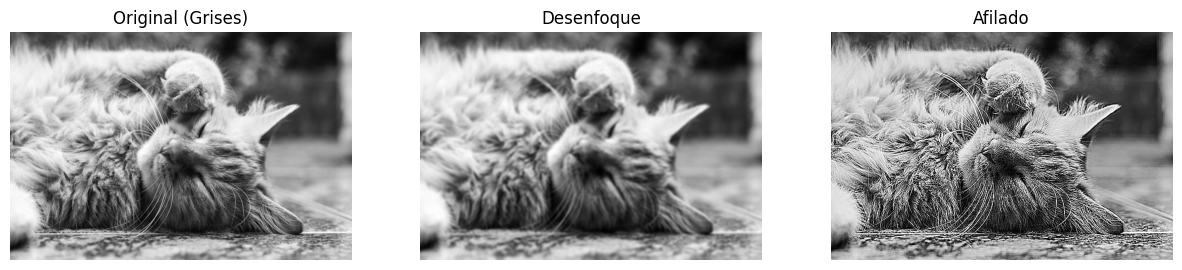

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Verificar que img_gray está definida
try:
    if img_gray is None:
        raise ValueError("La imagen img_gray no está definida. Ejecuta las celdas anteriores.")
except NameError:
    raise NameError("La variable img_gray no está definida. Asegúrate de cargar la imagen primero.")

# Función para generar un kernel de afilado dinámico
def create_sharpening_kernel(ksize):
    kernel = np.zeros((ksize, ksize), np.float32)
    center = ksize // 2
    alpha = 2.0  # Factor de amplificación
    kernel[center, center] = 1 + alpha * ksize
    kernel[center-1, center] = -alpha * ksize / 4
    kernel[center+1, center] = -alpha * ksize / 4
    kernel[center, center-1] = -alpha * ksize / 4
    kernel[center, center+1] = -alpha * ksize / 4
    return kernel

# Definir kernels
kernel_blur = np.ones((5, 5), np.float32) / 25  # Kernel de desenfoque (5x5 promedio)
kernel_sharpen = create_sharpening_kernel(5)  # Kernel de afilado (5x5 dinámico)

# Aplicar filtros
img_blur = cv2.filter2D(img_gray, -1, kernel_blur)
img_sharpen = cv2.filter2D(img_gray, -1, kernel_sharpen)

# Visualizar resultados
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title('Original (Grises)')
plt.imshow(img_gray, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Desenfoque')
plt.imshow(img_blur, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Afilado')
plt.imshow(img_sharpen, cmap='gray')
plt.axis('off')

plt.show()

## 4. Detección de Bordes

Implementamos dos métodos de detección de bordes:
- **Filtro Sobel**: Detecta bordes en direcciones X e Y por separado, resaltando gradientes horizontales y verticales.
- **Filtro Laplaciano**: Detecta bordes omnidireccionales mediante la segunda derivada.

Convertimos las imágenes a tipo `float32` para evitar problemas con valores negativos.

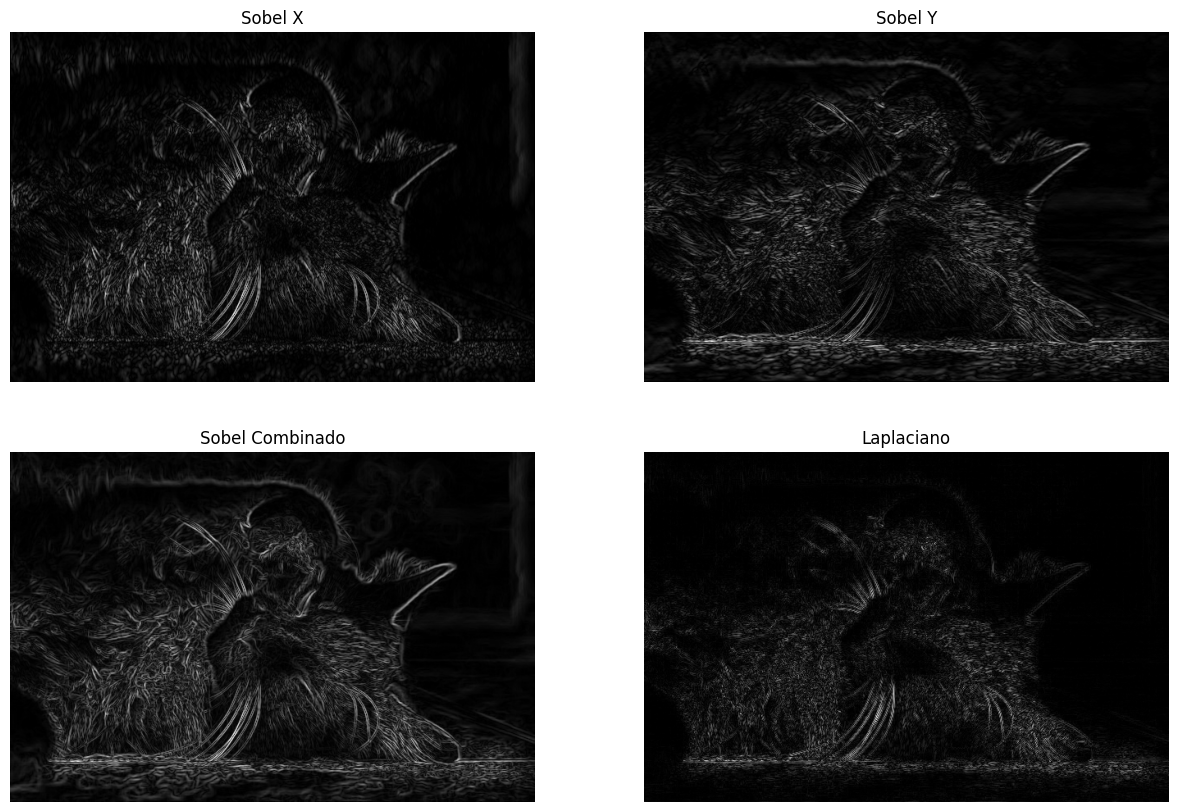

In [4]:
# Usar la imagen en escala de grises original (uint8) o convertir a float64
# Opción 1: Usar img_gray (uint8) directamente
img_input = img_gray  # uint8, no requiere conversión

# Filtro Sobel (X e Y)
sobel_x = cv2.Sobel(img_input, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_input, cv2.CV_64F, 0, 1, ksize=3)

# Combinar Sobel X e Y (magnitud del gradiente)
sobel_combined = np.sqrt(sobel_x**2 + sobel_y**2)

# Filtro Laplaciano
laplacian = cv2.Laplacian(img_input, cv2.CV_64F, ksize=3)

# Normalizar resultados para visualización
sobel_x = cv2.normalize(np.abs(sobel_x), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
sobel_y = cv2.normalize(np.abs(sobel_y), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
sobel_combined = cv2.normalize(sobel_combined, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
laplacian = cv2.normalize(np.abs(laplacian), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Visualizar resultados
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.title('Sobel X')
plt.imshow(sobel_x, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title('Sobel Y')
plt.imshow(sobel_y, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title('Sobel Combinado')
plt.imshow(sobel_combined, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title('Laplaciano')
plt.imshow(laplacian, cmap='gray')
plt.axis('off')

plt.show()

## 5. Sliders para Ajuste de Parámetros (Bonus)

En Google Colab, las ventanas gráficas de OpenCV (`cv2.imshow`, `cv2.createTrackbar`) no son compatibles, por lo que usamos sliders interactivos con `ipywidgets` para ajustar dos parámetros en tiempo real:
- **Tamaño del kernel**: Controla el tamaño de la matriz de convolución (impar, entre 3 y 15) para ambos filtros. Kernels más grandes intensifican el efecto.
- **Tipo de filtro**: Selecciona entre desenfoque (Blur) y afilado (Sharpening).

El filtro Blur suaviza la imagen, mientras que Sharpening realza los detalles, haciéndola más nítida. Usa los sliders para explorar los efectos en la imagen.

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
%matplotlib inline

# Verificar que img_gray está definida
try:
    if img_gray is None:
        raise ValueError("La imagen img_gray no está definida. Ejecuta las celdas anteriores.")
except NameError:
    raise NameError("La variable img_gray no está definida. Asegúrate de cargar la imagen primero.")


# Función para aplicar el filtro y mostrar el resultado
def apply_filter(ksize, filter_type):
    try:
        # Asegurar que ksize sea impar y mayor o igual a 3
        ksize = max(3, ksize | 1)

        # Seleccionar el kernel según el tipo de filtro
        if filter_type == 0:  # Blur
            kernel = np.ones((ksize, ksize), np.float32) / (ksize * ksize)
            filter_name = "Blur"
        else:  # Sharpening
            kernel = create_sharpening_kernel(ksize)
            filter_name = "Sharpening"

        # Aplicar filtro
        img_filtered = cv2.filter2D(img_gray, -1, kernel)

        # Mostrar imagen con Matplotlib
        plt.figure(figsize=(8, 8))  # Aumentar tamaño para ver detalles
        plt.title(f'{filter_name} (Kernel {ksize}x{ksize})')
        plt.imshow(img_filtered, cmap='gray')
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"Error al aplicar el filtro: {e}")

# Crear sliders interactivos
interact(apply_filter,
         ksize=IntSlider(min=3, max=15, step=2, value=3, description='Kernel Size'),
         filter_type=IntSlider(min=0, max=1, step=1, value=0, description='Filter Type (0=Blur, 1=Sharpening)'))

interactive(children=(IntSlider(value=3, description='Kernel Size', max=15, min=3, step=2), IntSlider(value=0,…

<function __main__.apply_filter(ksize, filter_type)>